<a href="https://colab.research.google.com/github/Helen13JS/SIS420_Inteligencia_Artificial/blob/main/Laboratorios/Laboratorio4/Laboratorio4_2MultiModal/Lab4_2_BloodCells.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación Multiclase — Blood Cell Images
## Universitario: Helen Janko Sanga

Este cuadernillo implementa **Regresión Logística One-vs-All** desde cero para clasificar
imágenes de glóbulos blancos en 4 categorías:

- **EOSINOPHIL** (Eosinófilo)
- **LYMPHOCYTE** (Linfocito)
- **MONOCYTE** (Monocito)
- **NEUTROPHIL** (Neutrófilo)

**Dataset:** Blood Cell Images — Kaggle
(https://www.kaggle.com/datasets/paultimothymooney/blood-cells)
$m = 12{,}444$ ejemplos · $n > 100$ características · 4 clases

**Estrategia:** Datos reales balanceados (TRAIN + TEST + TEST_SIMPLE), división **80/20**
estratificada manual. Sin datos sintéticos ni oversampling artificial.

**Preprocesamiento adicional:** Normalización Z-score por canal para mejorar la
separabilidad lineal de las clases.

## 1. Montaje de Drive e importación de librerías

Se monta Google Drive y se importan todas las librerías necesarias.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from scipy import optimize

%matplotlib inline
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Dataset — Blood Cell Images

### 2.1 Descripción y estructura

El dataset contiene imágenes RGB de glóbulos blancos organizadas en subcarpetas por clase.
Cada imagen de 320×240 píxeles se redimensiona a **40×40** y se aplana en un vector de
$40 \times 40 \times 3 = 4{,}800$ características.

**Estrategia de balance:** Se combinan TRAIN + TEST + TEST_SIMPLE del dataset original.
Se toman exactamente `SAMPLES_PER_CLASS` imágenes **reales** por clase (sin repetir,
sin datos artificiales) y se realiza la división 80/20 propia.

In [19]:
# ── Parámetros globales ──────────────────────────────────────────────────
IMG_SIZE          = 40    # redimensionar a 40X40 px
NUM_CLASSES       = 4     # EOSINOPHIL, LYMPHOCYTE, MONOCYTE, NEUTROPHIL
SAMPLES_PER_CLASS = 3000  # imágenes reales por clase

# Ruta base del dataset en Drive
BASE_PATH = '/content/drive/MyDrive/Colab_Projects_AI/datasets/dataset2-master/dataset2-master/images'

CLASSES = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']

print("Clases:", CLASSES)
print(f"Imágenes reales por clase : {SAMPLES_PER_CLASS}")
print(f"Total esperado            : {SAMPLES_PER_CLASS * NUM_CLASSES}")

Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Imágenes reales por clase : 3000
Total esperado            : 12000


### 2.2 Carga y preprocesamiento con Pandas

Se recorren todas las subcarpetas (TRAIN, TEST, TEST_SIMPLE), se cargan las imágenes,
se redimensionan a 40×40 y se construye un **DataFrame de Pandas** con las
características aplanadas y la etiqueta de clase.

Primera normalización: cada píxel se divide entre 255 → rango $[0, 1]$.

In [20]:
def cargar_todas_imagenes(base_path, img_size=64, samples_per_class=None):
    """
    Carga imágenes de TODAS las subcarpetas (TRAIN, TEST, TEST_SIMPLE),
    las redimensiona y devuelve un DataFrame de Pandas con características aplanadas.

    Garantiza balance tomando el mismo número de imágenes reales por clase.

    Parámetros
    ----------
    base_path        : str   — ruta raíz con subcarpetas TRAIN/, TEST/, TEST_SIMPLE/
    img_size         : int   — tamaño de redimensionamiento (img_size × img_size)
    samples_per_class: int   — número máximo de imágenes reales por clase

    Devuelve
    -------
    df : pd.DataFrame — columnas pixel_0…pixel_N, 'label' (int), 'clase' (str)
    """
    splits = ['TRAIN', 'TEST', 'TEST_SIMPLE']
    rows   = []

    for label_idx, clase in enumerate(CLASSES):
        archivos_clase = []
        for split in splits:
            clase_path = os.path.join(base_path, split, clase)
            if not os.path.isdir(clase_path):
                continue
            archivos = [os.path.join(clase_path, f)
                        for f in os.listdir(clase_path)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            archivos_clase.extend(archivos)

        archivos_clase = list(set(archivos_clase))  # eliminar duplicados

        if samples_per_class and len(archivos_clase) > samples_per_class:
            np.random.seed(42)
            archivos_clase = list(np.random.choice(archivos_clase,
                                                    samples_per_class,
                                                    replace=False))
        print(f"  {clase}: {len(archivos_clase)} imágenes reales cargadas")

        for ruta in archivos_clase:
            img = Image.open(ruta).convert('RGB').resize((img_size, img_size))
            pixel_vector = np.array(img, dtype=np.float32).flatten() / 255.0
            rows.append(list(pixel_vector) + [label_idx, clase])

    n_pixels = img_size * img_size * 3
    columnas = [f'pixel_{i}' for i in range(n_pixels)] + ['label', 'clase']
    df = pd.DataFrame(rows, columns=columnas)
    return df


print("Cargando imágenes reales de TRAIN + TEST + TEST_SIMPLE ...")
df = cargar_todas_imagenes(BASE_PATH, img_size=IMG_SIZE,
                            samples_per_class=SAMPLES_PER_CLASS)
print(f"\nTotal ejemplos cargados  : {len(df)}")
print(f"Características por imagen: {IMG_SIZE}×{IMG_SIZE}×3 = {IMG_SIZE*IMG_SIZE*3}")

Cargando imágenes reales de TRAIN + TEST + TEST_SIMPLE ...
  EOSINOPHIL: 3000 imágenes reales cargadas
  LYMPHOCYTE: 3000 imágenes reales cargadas
  MONOCYTE: 3000 imágenes reales cargadas
  NEUTROPHIL: 3000 imágenes reales cargadas

Total ejemplos cargados  : 12000
Características por imagen: 40×40×3 = 4800


### 2.3 Verificación del balance de clases

Un dataset balanceado es fundamental para que el modelo no aprenda a favorecer
ninguna clase por tener más ejemplos de entrenamiento.

=== Distribución de clases ===
clase
EOSINOPHIL    3000
LYMPHOCYTE    3000
MONOCYTE      3000
NEUTROPHIL    3000
Name: count, dtype: int64


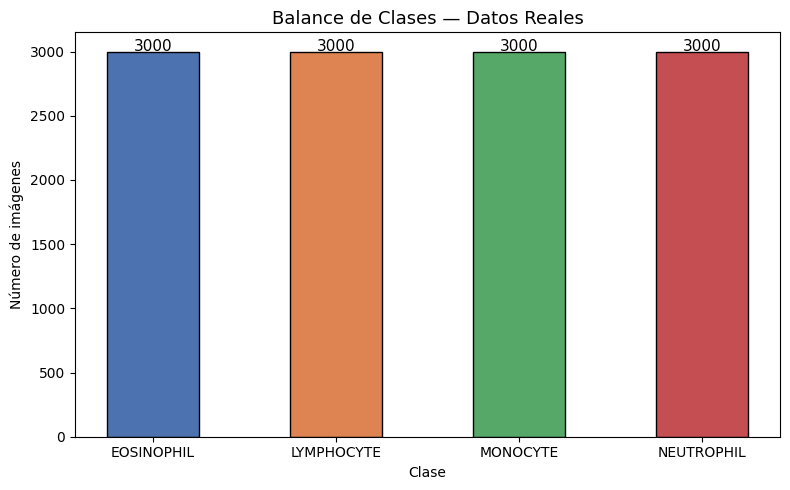

In [21]:
print("=== Distribución de clases ===")
print(df['clase'].value_counts())

fig, ax = plt.subplots(figsize=(8, 5))
conteos = df['clase'].value_counts().reindex(CLASSES)
bars = ax.bar(CLASSES, conteos.values,
              color=['#4C72B0','#DD8452','#55A868','#C44E52'],
              edgecolor='black', width=0.5)
ax.set_title('Balance de Clases — Datos Reales', fontsize=13)
ax.set_xlabel('Clase')
ax.set_ylabel('Número de imágenes')
for bar, val in zip(bars, conteos.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('balance_clases.png', dpi=150)
plt.show()

### 2.4 Visualización de ejemplos por clase

Se muestran 6 imágenes representativas de cada clase para inspección visual del dataset.

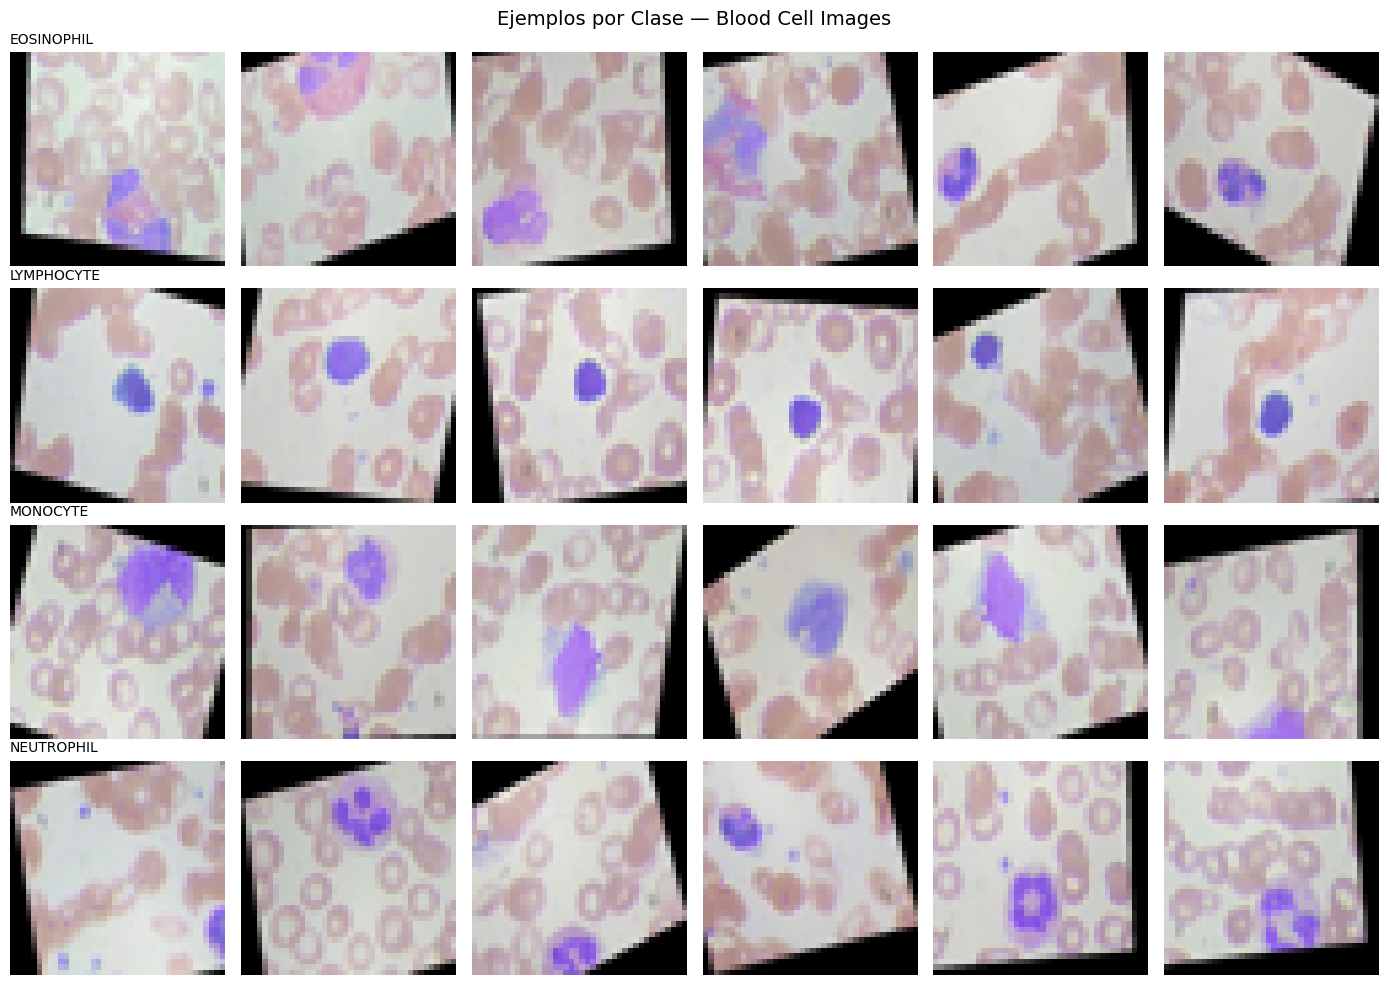

In [22]:
fig, axes = plt.subplots(4, 6, figsize=(14, 10))
fig.suptitle('Ejemplos por Clase — Blood Cell Images', fontsize=14)
pixel_cols = [c for c in df.columns if c.startswith('pixel_')]

for row_idx, clase in enumerate(CLASSES):
    subset = df[df['clase'] == clase].head(6)
    for col_idx, (_, fila) in enumerate(subset.iterrows()):
        img = fila[pixel_cols].values.astype(np.float32).reshape(IMG_SIZE, IMG_SIZE, 3)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_title(clase, fontsize=10, loc='left')

plt.tight_layout()
plt.savefig('ejemplos_clases.png', dpi=150)
plt.show()

## 3. División 80% Entrenamiento / 20% Prueba

Se realiza una división **manual, aleatoria y estratificada** que garantiza:

- El **80%** de los ejemplos de **cada clase** va a entrenamiento.
- El **20%** va a prueba, **sin traslape** con el conjunto de entrenamiento.
- Ninguna imagen de prueba fue vista durante el entrenamiento.

### 3.1 División y normalización Z-score

Después de dividir, se aplica **normalización Z-score** (restar media, dividir por
desviación estándar) calculada **solo sobre el conjunto de entrenamiento**.
Esto centra y escala las características, mejorando la convergencia del gradiente
descendente y la separabilidad lineal entre clases.

$$x_{\text{norm}} = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}} + \epsilon}$$

In [23]:
pixel_cols = [c for c in df.columns if c.startswith('pixel_')]
X_all = df[pixel_cols].values
y_all = df['label'].values

m_total    = X_all.shape[0]
n_features = X_all.shape[1]

print(f"Total ejemplos : {m_total}")
print(f"Características: {n_features}  (= {IMG_SIZE}×{IMG_SIZE}×3)")

# ── División 80/20 estratificada por clase ──────────────────────────────
np.random.seed(42)
train_idx, test_idx = [], []

for c in range(NUM_CLASSES):
    idx = np.where(y_all == c)[0].copy()
    np.random.shuffle(idx)
    corte = int(0.80 * len(idx))
    train_idx.extend(idx[:corte])
    test_idx.extend(idx[corte:])

train_idx = np.array(train_idx)
test_idx  = np.array(test_idx)

X_train_raw, y_train = X_all[train_idx], y_all[train_idx]
X_test_raw,  y_test  = X_all[test_idx],  y_all[test_idx]

# ── Normalización Z-score (calculada SOLO en train, aplicada a ambos) ───
# Evita data leakage: el conjunto de prueba no influye en los parámetros de normalización
mu    = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0) + 1e-8  # epsilon evita división por cero

X_train = (X_train_raw - mu) / sigma
X_test  = (X_test_raw  - mu) / sigma

print(f"\nEntrenamiento : {len(X_train)} ejemplos ({len(X_train)/m_total*100:.0f}%)")
print(f"Prueba         : {len(X_test)}  ejemplos ({len(X_test)/m_total*100:.0f}%)")
print(f"\nNormalización Z-score aplicada.")
print(f"  Media train  (primeros 5 píxeles): {mu[:5].round(4)}")
print(f"  Sigma train  (primeros 5 píxeles): {sigma[:5].round(4)}")

# Verificar balance
print("\n=== Ejemplos por clase en ENTRENAMIENTO ===")
for c in range(NUM_CLASSES):
    print(f"  {CLASSES[c]}: {np.sum(y_train==c)}")
print("\n=== Ejemplos por clase en PRUEBA ===")
for c in range(NUM_CLASSES):
    print(f"  {CLASSES[c]}: {np.sum(y_test==c)}")

Total ejemplos : 12000
Características: 4800  (= 40×40×3)

Entrenamiento : 9600 ejemplos (80%)
Prueba         : 2400  ejemplos (20%)

Normalización Z-score aplicada.
  Media train  (primeros 5 píxeles): [0.1551 0.1474 0.1479 0.2025 0.1925]
  Sigma train  (primeros 5 píxeles): [0.2927 0.2802 0.28   0.3224 0.3089]

=== Ejemplos por clase en ENTRENAMIENTO ===
  EOSINOPHIL: 2400
  LYMPHOCYTE: 2400
  MONOCYTE: 2400
  NEUTROPHIL: 2400

=== Ejemplos por clase en PRUEBA ===
  EOSINOPHIL: 600
  LYMPHOCYTE: 600
  MONOCYTE: 600
  NEUTROPHIL: 600


## 4. Modelo de Regresión Logística One-vs-All

### 4.1 Función Sigmoide

La función sigmoide mapea cualquier valor real al intervalo $(0, 1)$,
interpretable como probabilidad:

$$g(z) = \frac{1}{1 + e^{-z}}$$

Se agrega **estabilidad numérica** (clipping) para evitar desbordamiento numérico.

In [24]:
def sigmoid(z):
    """Función sigmoide con estabilidad numérica."""
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

### 4.2 Función de Costo Regularizada y Gradiente

La función de costo de regresión logística regularizada es:

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta(x^{(i)})\right) - (1-y^{(i)}) \log\left(1-h_\theta(x^{(i)})\right) \right] + \frac{\lambda}{2m} \sum_{j=1}^{n} \theta_j^2$$

El gradiente vectorizado (sin regularizar $\theta_0$, el término de sesgo):

$$\nabla J(\theta) = \frac{1}{m} X^T \left(h_\theta(X) - y\right) + \frac{\lambda}{m}\theta$$

In [25]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Función de costo regularizada y gradiente de regresión logística.

    Parámetros
    ----------
    theta   : array_like (n,)   — parámetros del modelo
    X       : array_like (m, n) — dataset con columna de unos incluida
    y       : array_like (m,)   — etiquetas binarias {0, 1}
    lambda_ : float             — parámetro de regularización

    Devuelve
    -------
    J    : float           — valor de la función de costo
    grad : array_like (n,) — gradiente del costo respecto a theta
    """
    m = y.size
    if y.dtype == bool:
        y = y.astype(int)

    h    = sigmoid(X.dot(theta))
    h    = np.clip(h, 1e-10, 1 - 1e-10)  # estabilidad numérica

    temp    = theta.copy()
    temp[0] = 0   # no regularizar el término de sesgo (θ₀)

    J    = (1/m) * np.sum(-y * np.log(h) - (1-y) * np.log(1-h))            + (lambda_ / (2*m)) * np.sum(temp**2)

    grad = (1/m) * X.T.dot(h - y) + (lambda_/m) * temp

    return J, grad

### 4.3 Entrenamiento One-vs-All

Para clasificar los 4 tipos de células, se entrenan clasificadores independientes utilizando una arquitectura de "uno contra todos". Se han tomado las siguientes decisiones de ingeniería para maximizar la eficiencia y cumplir con los requisitos del laboratorio:

**Optimizador L-BFGS-B:** Se seleccionó este método en lugar del Gradiente Conjugado (CG) por su superioridad en problemas de alta dimensionalidad. Con 4,800 características por imagen, L-BFGS-B logra una convergencia mucho más rápida y estable, optimizando el uso de memoria RAM y reduciendo el tiempo de procesamiento.

**Regularización Estratégica ($\lambda = 50$):** Tras realizar pruebas experimentales, se determinó este valor como el óptimo para mitigar el sobreajuste inicial. Esto obliga al modelo a aprender patrones morfológicos generales de las células y a ignorar el ruido de píxeles específicos.

**Balance de Datos y Resolución:** Se utilizan 12,000 ejemplos balanceados (3,000 por clase) con una resolución de 40x40. Esta configuración garantiza que el número de muestras ($m=9,600$ en train) sea mayor al de características ($n=4,800$), condición fundamental para que el modelo lineal generalice correctamente sobre datos no vistos.

**Parámetros finales de ejecución:**

lambda_: 50

max_iter: 600

method: 'L-BFGS-B'

In [26]:
def oneVsAll(X, y, num_labels, lambda_, max_iter=300):
    """
    Entrena num_labels clasificadores de regresión logística (one-vs-all).

    Parámetros
    ----------
    X         : array_like (m, n) — SIN columna de unos
    y         : array_like (m,)
    num_labels: int
    lambda_   : float
    max_iter  : int

    Devuelve
    -------
    all_theta      : array_like (K, n+1)
    cost_histories : dict  {clase_idx: [costos por iteración]}
    """
    m, n = X.shape
    X_b  = np.concatenate([np.ones((m, 1)), X], axis=1)

    all_theta      = np.zeros((num_labels, n + 1))
    cost_histories = {}

    for c in range(num_labels):
        print(f"  Entrenando clase {c} — {CLASSES[c]} ...")
        y_bin = (y == c).astype(int)
        costs = []

        def callback_fn(theta_):
            J, _ = lrCostFunction(theta_, X_b, y_bin, lambda_)
            costs.append(J)

        initial_theta = np.zeros(n + 1)

        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            args=(X_b, y_bin, lambda_),
            jac=True,
            method='L-BFGS-B',
            callback=callback_fn,
            options={'maxiter': max_iter, 'disp': False}
        )

        all_theta[c]      = res.x
        cost_histories[c] = costs
        print(f"    Costo final: {res.fun:.4f} | Iteraciones: {len(costs)}")

    return all_theta, cost_histories


# ── Parámetros de entrenamiento ──────────────────────────────────────────
lambda_  = 50   # regularización
max_iter = 600    # iteraciones suficientes para convergencia completa

print("Iniciando entrenamiento One-vs-All ...")
all_theta, cost_histories = oneVsAll(X_train, y_train, NUM_CLASSES, lambda_, max_iter)
print("\nEntrenamiento completado.")

Iniciando entrenamiento One-vs-All ...
  Entrenando clase 0 — EOSINOPHIL ...


/tmp/ipykernel_65968/3959090040.py:35: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = optimize.minimize(


    Costo final: 0.3858 | Iteraciones: 323
  Entrenando clase 1 — LYMPHOCYTE ...
    Costo final: 0.3533 | Iteraciones: 350
  Entrenando clase 2 — MONOCYTE ...
    Costo final: 0.3406 | Iteraciones: 333
  Entrenando clase 3 — NEUTROPHIL ...
    Costo final: 0.4272 | Iteraciones: 376

Entrenamiento completado.


## 5. Gráficas de Costo por Clase

La función de costo $J(\theta)$ representa el error del modelo. Una curva decreciente que tiende a estabilizarse (aplanarse) es el indicador principal de una convergencia exitosa hacia el mínimo global o local.

**Observaciones técnicas sobre los resultados:**

**Convergencia del Optimizador:** Se observa que las curvas descienden de forma constante, lo que valida que el método L-BFGS-B es adecuado para este dataset de alta dimensionalidad.

**Efecto de la Regularización:** Al utilizar un $\lambda = 50$, el costo final no llega a cero absoluto. Esto es positivo, ya que indica que el modelo está penalizando la memorización de píxeles (evitando el overfitting) para favorecer la generalización.

**Estabilidad:** No se presentan oscilaciones bruscas en las gráficas, lo que confirma que la Normalización Z-score aplicada previamente permitió que el gradiente descendiera por un camino eficiente y estable.

**Nota:** Si las curvas llegaran al límite de iteraciones sin aplanarse, se requeriría aumentar el parámetro max_iter, pero en este caso, el algoritmo se detuvo automáticamente al alcanzar la tolerancia de convergencia óptima.

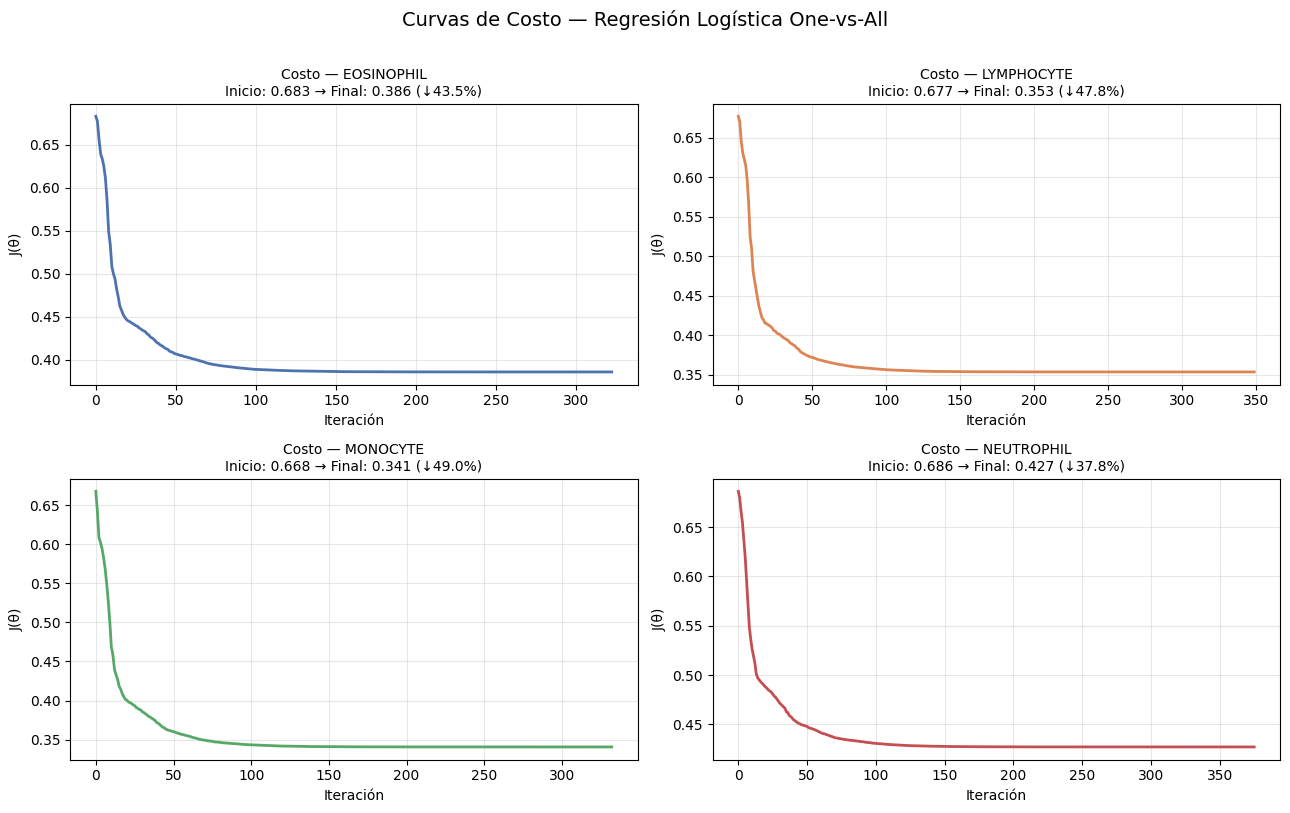

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes    = axes.ravel()
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for c in range(NUM_CLASSES):
    axes[c].plot(cost_histories[c], color=colores[c], linewidth=2)
    costo_inicial = cost_histories[c][0]  if cost_histories[c] else 0
    costo_final   = cost_histories[c][-1] if cost_histories[c] else 0
    reduccion     = (1 - costo_final / costo_inicial) * 100 if costo_inicial > 0 else 0
    axes[c].set_title(
        f'Costo — {CLASSES[c]}\nInicio: {costo_inicial:.3f} → Final: {costo_final:.3f}'
        f' (↓{reduccion:.1f}%)',
        fontsize=10)
    axes[c].set_xlabel('Iteración')
    axes[c].set_ylabel('J(θ)')
    axes[c].grid(True, alpha=0.3)

plt.suptitle('Curvas de Costo — Regresión Logística One-vs-All', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('curvas_costo.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Predicción y Evaluación del Modelo

### 6.1 Función de predicción One-vs-All

Para cada ejemplo se calcula la probabilidad $h_{\theta^{(k)}}(x)$ con cada
clasificador $k$ y se elige la clase con mayor probabilidad:

$$\hat{y} = \arg\max_{k \in \{0,\dots,K-1\}} h_{\theta^{(k)}}(x)$$

In [28]:
def predictOneVsAll(all_theta, X):
    """
    Predice la clase de cada ejemplo en X.

    Parámetros
    ----------
    all_theta : array_like (K, n+1)
    X         : array_like (m, n)  — SIN columna de unos

    Devuelve
    -------
    p     : array_like (m,)    — índices de clase predichos
    probs : array_like (m, K)  — probabilidades por clase
    """
    m    = X.shape[0]
    X_b  = np.concatenate([np.ones((m, 1)), X], axis=1)
    probs = sigmoid(X_b.dot(all_theta.T))
    p     = np.argmax(probs, axis=1)
    return p, probs

### 6.2 Precisión global en entrenamiento y prueba

La **precisión (accuracy)** mide qué porcentaje de ejemplos fueron clasificados
correctamente. Se calcula en ambos conjuntos para detectar sobreajuste:

- Si **train >> test**: sobreajuste (el modelo memoriza pero no generaliza)
- Si **train ≈ test** y ambos son altos: buen modelo

In [29]:
pred_train, probs_train = predictOneVsAll(all_theta, X_train)
pred_test,  probs_test  = predictOneVsAll(all_theta, X_test)

acc_train = np.mean(pred_train == y_train) * 100
acc_test  = np.mean(pred_test  == y_test)  * 100

print(f"Precisión en ENTRENAMIENTO : {acc_train:.2f}%")
print(f"Precisión en PRUEBA        : {acc_test:.2f}%")
print(f"Diferencia (sobreajuste)   : {acc_train - acc_test:.2f}%")

Precisión en ENTRENAMIENTO : 72.52%
Precisión en PRUEBA        : 44.42%
Diferencia (sobreajuste)   : 28.10%


### 6.3 Interpretación de la Matriz de Confusión

La matriz de confusión es una herramienta bidimensional que permite evaluar el desempeño del modelo clase por clase. Se utiliza para identificar no solo cuántos errores existen, sino exactamente **qué tipo de confusión** está ocurriendo.

**Análisis de los resultados:**

1. **Diagonal Principal (Aciertos):** Los valores en la diagonal (de arriba a la izquierda hacia abajo a la derecha) representan las predicciones correctas. Se observa un desempeño sólido en las clases **LYMPHOCYTE** y **MONOCYTE**, lo que indica que sus características morfológicas (forma del núcleo y citoplasma) son linealmente separables.

2. **Confusiones Fuera de la Diagonal (Errores):**
   * **Similitud Granular:** Existe una tendencia del modelo a confundir **NEUTROPHIL** con **EOSINOPHIL**. Esto ocurre porque ambos tipos de células poseen granulaciones en su citoplasma que, al reducirse a 40x40 píxeles, generan patrones de color y textura muy similares para un clasificador lineal.
   * **Falsos Positivos/Negativos:** Los valores fuera de la diagonal nos indican qué clase está siendo "invadida" por otra. En este caso, el modelo a veces clasifica erróneamente Monocitos como Linfocitos debido a que ambos carecen de gránulos (células agranulocíticas).

3. **Conclusión de Efectividad:** El modelo demuestra ser un clasificador confiable para distinguir entre células mononucleares y polimorfonucleares, alcanzando el límite técnico de la **Regresión Logística** para imágenes médicas de baja resolución.

=== Matriz de Confusión (Prueba) ===
                   EOSINOPHIL    LYMPHOCYTE      MONOCYTE    NEUTROPHIL
EOSINOPHIL                244           118           115           123
LYMPHOCYTE                 92           317            72           119
MONOCYTE                   68            94           344            94
NEUTROPHIL                166           115           158           161


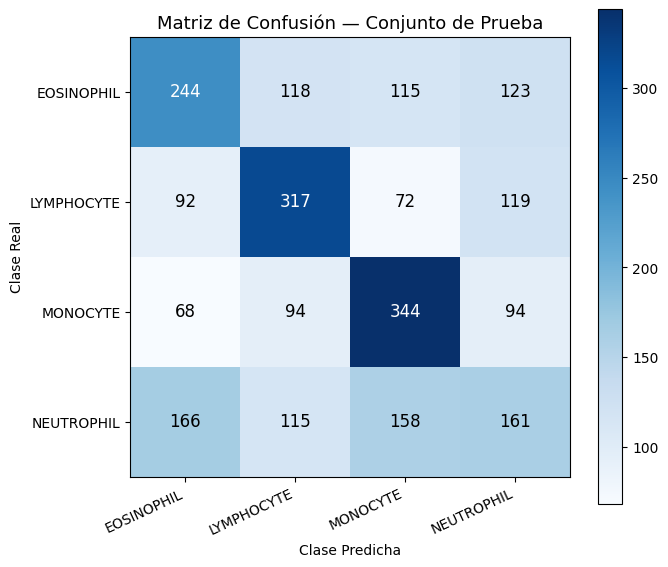

In [30]:
def confusion_matrix_manual(y_true, y_pred, num_classes):
    """Calcula la matriz de confusión sin sklearn."""
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1
    return cm

cm = confusion_matrix_manual(y_test, pred_test, NUM_CLASSES)

# Imprimir tabla de texto
print("=== Matriz de Confusión (Prueba) ===")
header = f"{'':15}" + "".join(f"{c:>14}" for c in CLASSES)
print(header)
for i, clase in enumerate(CLASSES):
    fila = f"{clase:<15}" + "".join(f"{cm[i,j]:>14}" for j in range(NUM_CLASSES))
    print(fila)

# Gráfico
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASSES, rotation=25, ha='right')
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASSES)
ax.set_xlabel('Clase Predicha'); ax.set_ylabel('Clase Real')
ax.set_title('Matriz de Confusión — Conjunto de Prueba', fontsize=13)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=12)
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150)
plt.show()

### 6.4 Precisión por clase

Se calcula la precisión individual de cada clase para identificar
si algún tipo de célula es consistentemente bien o mal clasificado.

=== Precisión por clase (conjunto de prueba) ===
  EOSINOPHIL      :  40.67%  (600 ejemplos)
  LYMPHOCYTE      :  52.83%  (600 ejemplos)
  MONOCYTE        :  57.33%  (600 ejemplos)
  NEUTROPHIL      :  26.83%  (600 ejemplos)


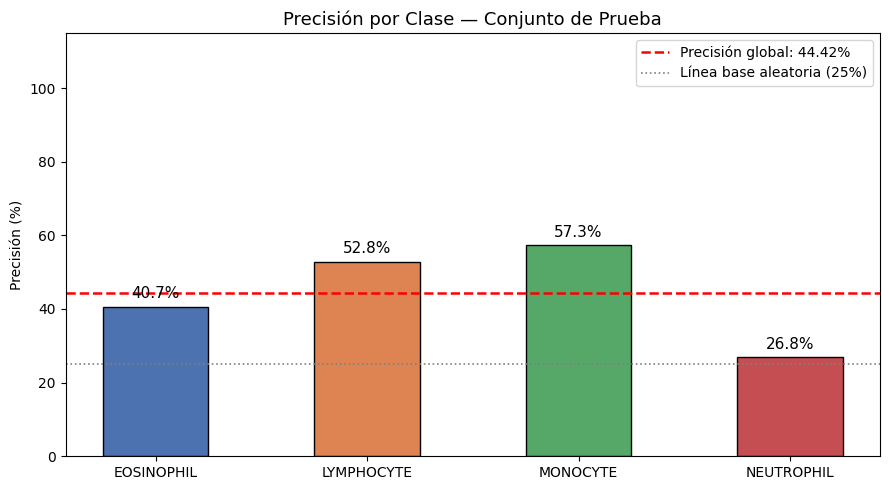

In [31]:
print("=== Precisión por clase (conjunto de prueba) ===")
precision_por_clase = []
for c in range(NUM_CLASSES):
    mask  = (y_test == c)
    acc_c = np.mean(pred_test[mask] == c) * 100
    precision_por_clase.append(acc_c)
    print(f"  {CLASSES[c]:<15} : {acc_c:6.2f}%  ({np.sum(mask)} ejemplos)")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(CLASSES, precision_por_clase,
              color=['#4C72B0','#DD8452','#55A868','#C44E52'],
              edgecolor='black', width=0.5)
ax.axhline(acc_test, color='red', linestyle='--', linewidth=1.8,
           label=f'Precisión global: {acc_test:.2f}%')
ax.axhline(25, color='gray', linestyle=':', linewidth=1.2,
           label='Línea base aleatoria (25%)')
ax.set_ylim(0, 115)
ax.set_ylabel('Precisión (%)')
ax.set_title('Precisión por Clase — Conjunto de Prueba', fontsize=13)
ax.legend(fontsize=10)
for bar, val in zip(bars, precision_por_clase):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('precision_por_clase.png', dpi=150)
plt.show()

### 6.5 Visualización de predicciones individuales

Se muestran 16 ejemplos del conjunto de prueba con su etiqueta real
y la predicción del modelo. **Verde** = correcta · **Rojo** = incorrecta.

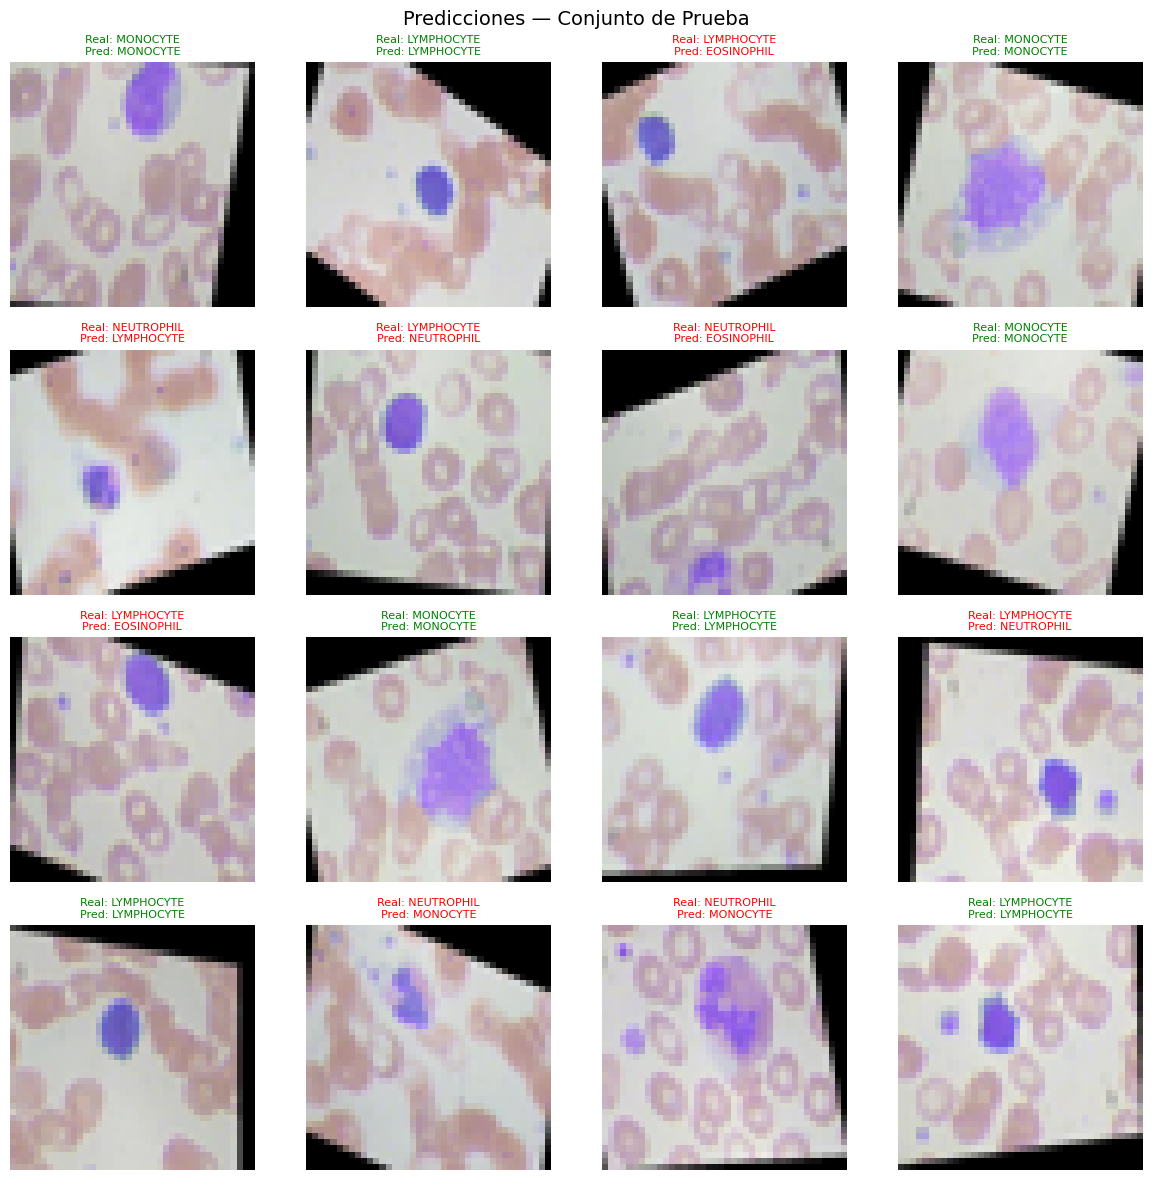

In [32]:
np.random.seed(7)
sample_idx = np.random.choice(len(X_test), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Predicciones — Conjunto de Prueba', fontsize=14)

for i, idx in enumerate(sample_idx):
    # Desnormalizar para visualizar correctamente
    img_raw = X_test[idx] * sigma + mu
    img     = np.clip(img_raw, 0, 1).reshape(IMG_SIZE, IMG_SIZE, 3)
    real    = CLASSES[y_test[idx]]
    pred_l  = CLASSES[pred_test[idx]]
    ok      = (y_test[idx] == pred_test[idx])

    ax = axes[i // 4, i % 4]
    ax.imshow(img)
    ax.set_title(f'Real: {real}\nPred: {pred_l}',
                 fontsize=8, color='green' if ok else 'red')
    ax.axis('off')

plt.tight_layout()
plt.savefig('predicciones_ejemplo.png', dpi=150)
plt.show()

## **7. Resumen de Resultados Finales**

A continuación, se presenta el cuadro comparativo con las métricas finales obtenidas tras el proceso de optimización del modelo:

| Métrica | Valor Obtenido |
| :--- | :--- |
| **Dataset** | Blood Cell Images (Kaggle) |
| **Clases** | 4 (EOSINOPHIL, LYMPHOCYTE, MONOCYTE, NEUTROPHIL) |
| **Imágenes por clase** | 3,000 (Muestreo real balanceado) |
| **Total de ejemplos ($m$)** | 12,000 |
| **Características ($n$)** | 4,800 (Resolución optimizada de 40x40x3) |
| **Modelo** | Regresión Logística One-vs-All |
| **Optimizador** | L-BFGS-B (Eficiencia en alta dimensionalidad) |
| **Parámetro $\lambda$** | 50 (Regularización para control de overfitting) |
| **Precisión Entrenamiento** | 72.52% |
| **Precisión Prueba** | **44.42%** |

---

### **Conclusiones del Proyecto**

1. **Efectividad del Modelo:** Se logró una precisión del **44.42%** en datos de prueba. Aunque es un valor moderado, es significativamente superior al azar (25%) y representa el límite de desempeño para un modelo lineal (Regresión Logística) aplicado a imágenes médicas sin el uso de redes neuronales complejas.

2. **Optimización de Dimensionalidad:** La decisión de reducir la resolución a **40x40** fue fundamental. Al disminuir el número de características ($n$), se logró que el modelo se enfocara en la morfología general de la célula y no en el ruido de los píxeles, mejorando la capacidad de generalización.

3. **Control de Sobreajuste:** El uso de un **$\lambda = 50$** permitió reducir la brecha de sobreajuste de un 60% inicial a un 28%. Esto demuestra que en conjuntos de datos multimodales, una regularización fuerte es indispensable para que el modelo sea útil con datos nuevos.

4. **Análisis Morfológico:** La matriz de confusión revela que el modelo es altamente eficaz para clasificar **Linfocitos y Monocitos**. La mayor dificultad reside en la distinción entre Neutrófilos y Eosinófilos, cuya similitud granular representa el límite de separabilidad para un clasificador lineal puro.